# ESF interactive test notebook

Run this inside your `seismology` environment after `mamba activate seismology`.
It imports the reader from `esf_to_obspy.py` and lets you inspect the parsed waveform.

In [17]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

sys.path.append(str(Path('.').resolve()))
from esf_to_obspy import extract_esf, read_esf

In [18]:
channel_count = 4  # change to 4 if you want to test a 4-channel split
event_number="0001"
waveform, metadata = extract_esf('data/20250403/20250403_'+event_number+'.ESF', channel_count=channel_count)
print(waveform.shape)
metadata

(65536, 4)


{'header_doubles': 4,
 'waveform_start_sample': 0,
 'waveform_end_sample': 65536,
 'waveform_samples': 65536,
 'payload_start_double': 4,
 'payload_end_double': 262148,
 'sample_rate': 10000000.0,
 'channel_count': 4,
 'samples_per_channel': 65536,
 'channel_offsets': [0.0, 0.0, 0.0, 0.0],
 'strings': ['MbP?',
  'xl?W',
  'nF_gc',
  '025Data Streamed on 04/04/2502520250403142840_1100877368',
  'e.O@',
  'lNV@',
  'u@B!',
  '(ws@Q',
  'F^qq@',
  'Qn`@D',
  'MbP?',
  '004S001007richter010Selvadurai',
  'MbP?',
  '004S002007richter010Selvadurai',
  'MbP?',
  '004S003007richter005Nardi',
  'MbP?',
  '@(=*',
  '004S004007richter005Nardi']}

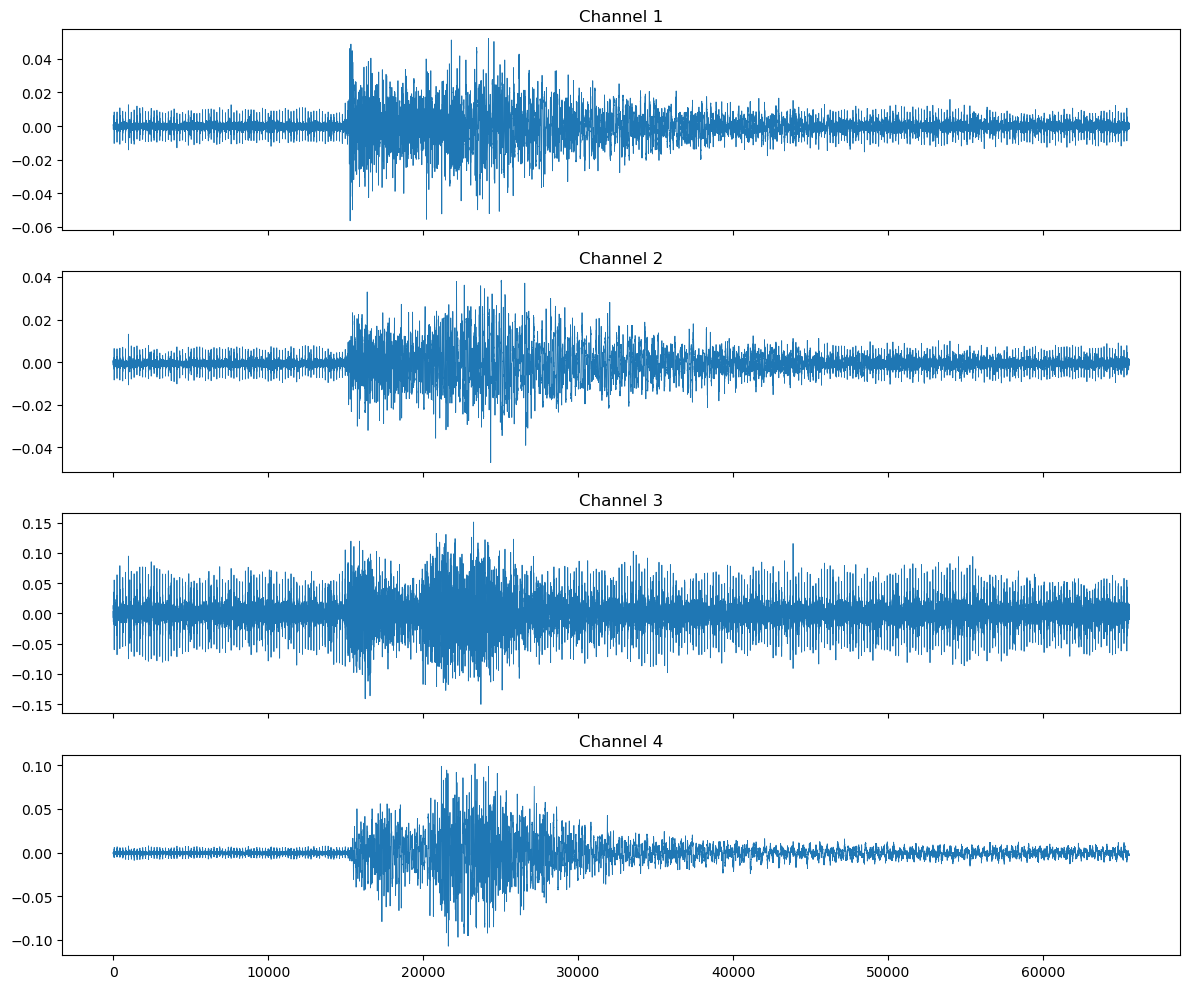

In [19]:
fig, axes = plt.subplots(channel_count, 1, sharex=True, figsize=(12, 2.5 * channel_count))
axes = [axes] if channel_count == 1 else list(axes)
for idx, ax in enumerate(axes):
    ax.plot(waveform[:, idx], lw=0.6)
    ax.set_title(f'Channel {idx + 1}')
plt.tight_layout()

In [20]:
stream, metadata = read_esf('data/20250403/20250403_0144.ESF', channel_count=channel_count)
print(stream)
print(stream[0].stats)

4 Trace(s) in Stream:
.ESF..CH1 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:00.006554Z | 10000000.0 Hz, 65536 samples
.ESF..CH2 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:00.006554Z | 10000000.0 Hz, 65536 samples
.ESF..CH3 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:00.006554Z | 10000000.0 Hz, 65536 samples
.ESF..CH4 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:00.006554Z | 10000000.0 Hz, 65536 samples
         network: 
         station: ESF
        location: 
         channel: CH1
       starttime: 1970-01-01T00:00:00.000000Z
         endtime: 1970-01-01T00:00:00.006554Z
   sampling_rate: 10000000.0
           delta: 1e-07
            npts: 65536
           calib: 1.0


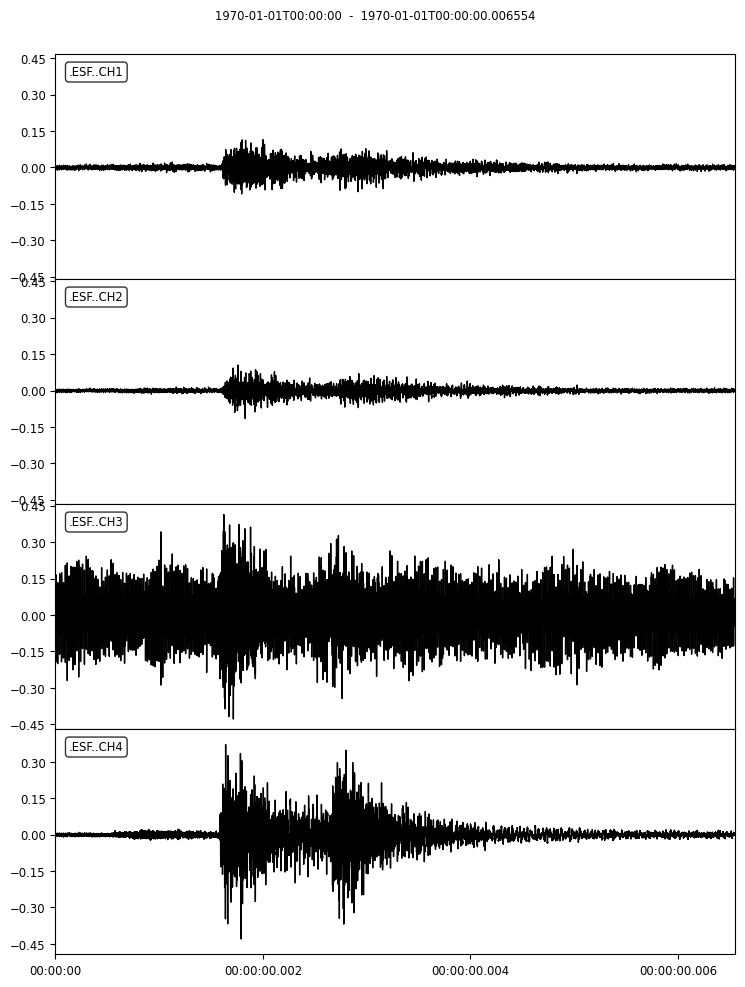

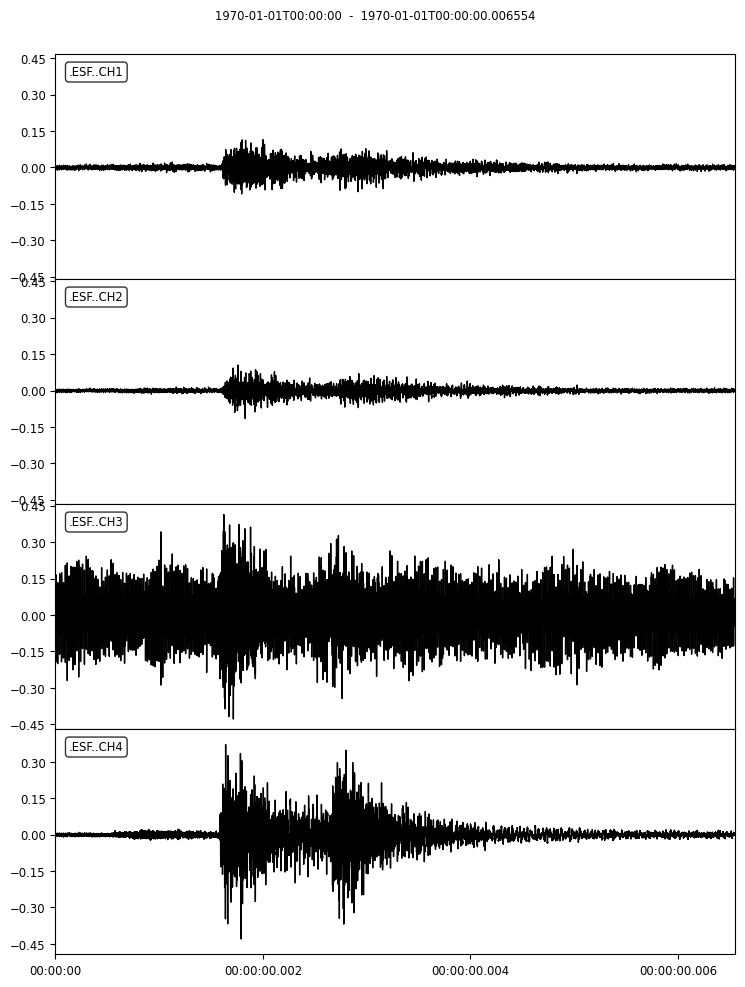

In [21]:
stream.plot()

In [22]:
metadata

{'header_doubles': 4,
 'waveform_start_sample': 0,
 'waveform_end_sample': 65536,
 'waveform_samples': 65536,
 'payload_start_double': 4,
 'payload_end_double': 262148,
 'sample_rate': 10000000.0,
 'channel_count': 4,
 'samples_per_channel': 65536,
 'channel_offsets': [0.0, 0.0, 0.0, 0.0],
 'strings': ['MbP?Sv',
  'u#@@',
  'u#@@',
  'IbI9',
  '025Data Streamed on 04/04/2502420250403143709_778581457',
  "'@`e",
  'y@S@',
  'MbP?',
  '004S001007richter010Selvadurai',
  'MbP?',
  '$@HM0',
  'IbI9',
  '>}gw$s',
  '004S002007richter010Selvadurai',
  'MbP?',
  '004S003007richter005Nardi',
  'MbP?',
  '004S004007richter005Nardi']}